# WORKING WITH FILES

It is very important to understand how to work with files in Python for a number of important reasons:
1. Data strorage and Retrieval - it is common to persist data (results of computations, documents, etc.) to disk to avoid losing this valuable commodity.  Of course, we will need to retrieve this data later to continue using it.  
2. Data Processing - data stored in files on disk can be loaded into an application which performs analysis on that data.  
3. Automation - writing a script that performs a task automatically (i.e., without human intervention) helps to save time and reduce manual effort.  These scripts will often interact with files when reading logs, generating reports, or processing data.
4. Interoperability - data can be shared between disparate systems by exchanging this data in a universal / common format (e.g., JSON, CSV, text, etc.).
5. Data Integrity and Security - to ensure data integrity (avoiding corruption, deletion, modification) and security (avoiding unauthorized access) requires a working knowledge of file handling.
6. Error handling - handling missing files, file permissions, and read/write errors gracefully in code.

In the cyber security field, working with files is valuable for a number of scenarios:
1. Log Analysis and Monitoring - very useful in scenarios like intrusion detection and audit trail analysis, files contain log entries of events which can be persisted to disk for further analysis.  This can alert network administrators of breaches or illegal and unauthorized activity.
2. Forensic Analysis - writing scripts for use in data recovery and evidence collection will need to recover data from files which have been damaged, corrupted or protected; whilst the automatic retrieval and preseveration of evidence is also important.
3. Configuration Management & Compliance - checking configuration files against policies automatically, by running scripts.  These scripts can also automatically backup and/or restore these configuration files.
4. Data Sanitization and Handling - encryption, securely deleting confidential or classified files, anonymising and masking sensitive data, and protection files from uauthorized access all require good working knowledge of file handling.
5. Vulnerability Scanning & Patch Management - the automation of vulnerability scans and software patch management is a common task.
6. Incident Reporting - responding automatically to events recorded in an event log, plus collecting log files centrally for better coordination of incident management requires file handling.

## OPEN - A BUILT-IN FUNCTION

The core of working with files is using the built-in Python function **open** (https://docs.python.org/3/library/functions.html#open).
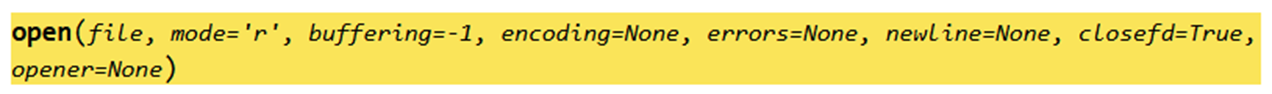

When opening different kinds of files (text or binary) and for different purposes (read, write, append, etc.) you must specify the **mode**:
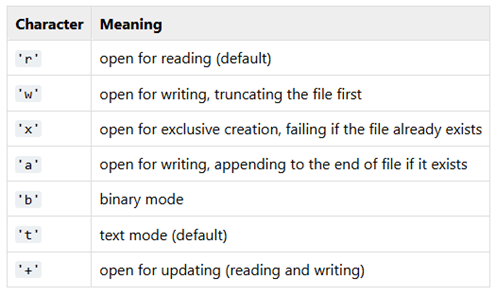

This **open** function returns a file object which you can use according to your intended purposes.


## TEXT FILES

In [1]:
%%HTML
<iframe width="560" height="315" src="https://www.youtube.com/embed/4mX0uPQFLDU?si=P9UE41d-C6N-moXg" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

In [2]:
# lets use what we learned in this video
filename = "animals.txt"
animals = ["dog", "cat", "elephant", "mouse", "chicken", "rat", "bat", "gnat"]
with open(filename, "w") as f:
    for animal in animals:
        print(animal, file=f)
    print("=" * 20, file=f)
    print(f"There are {len(animals)} animals.", file=f)
    print(f"{filename} saved.")

# reopen the file and update its contents by appending some "beatles" to the end
beatles = ["Paul McCarthy", "John Lennon", "Ringo Starr", "George Harrison"]
with open(filename, "a") as f:
    print("", file=f)
    for beatle in beatles:
        print(beatle, file=f)
    print("=" * 20, file=f)
    print(f"There are {len(beatles)} members of the Beatles.", file=f)
print(f"{filename} modified.")



animals.txt saved.
animals.txt modified.


In [3]:
# quickly read and display contents of a text file
with open('animals.txt') as f:
    text = f.read()
print(text)

dog
cat
elephant
mouse
chicken
rat
bat
gnat
There are 8 animals.

Paul McCarthy
John Lennon
Ringo Starr
George Harrison
There are 4 members of the Beatles.



## COMMA SEPARATED VALUES
A special kind of text file is the comma separated values (CSV) which stores data in fields for easy data processing.

In [4]:
%%HTML
<iframe width="560" height="315" src="https://www.youtube.com/embed/Xi52tx6phRU?si=GEKW-R6Qvl3Aztbt" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

In [1]:
# lets use what we learned in this video
import csv

filename = "google_stock_data.csv"
with open(filename) as csv_file:
    reader = csv.reader(csv_file)
    data = []
    header = next(reader) # read first line
    for row in reader:
        date = row[0]
        open = float(row[1])
        high = float(row[2])
        low = float(row[3])
        close = float(row[4])
        volume = int(row[5])
        adj_close = float(row[6])
        data.append([date, open, high, low, close, volume, adj_close])

print(header)
print(data[0])
print(f"{len(data)} records loaded.")

['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']
['8/19/2014', 585.002622, 587.342658, 584.002627, 586.862643, 978600, 586.862643]
2518 records loaded.


## JSON FILES
Java Script Object Notation (JSON) files are text files which are used commonly as a lightweight data format (similar to a Python dictionary or XML code).  It is very useful for transporting data between a client and a server.  Python has a special library which can be used to parse and send/recieve JSON files.

In [7]:
%%HTML
<iframe width="560" height="315" src="https://www.youtube.com/embed/pTT7HMqDnJw?si=CI3G43a8Z9lsjfvU" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

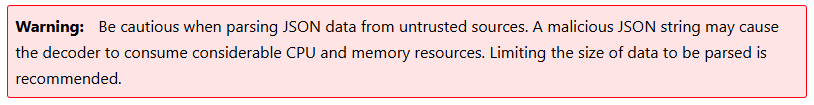

In [23]:
# lets use what we learned in this video
import json
from urllib.request import urlopen

# read json data from a server - this is a fake REST API for testing and learning (https://jsonplaceholder.typicode.com/)
# DO NOT DOWNLOAD DATA FROM UNTRUSTED JSON SITES
with urlopen('https://jsonplaceholder.typicode.com/users/') as response:
    source = response.read()

# the url request returns a string, which we convert to a json object for further processing
# the source data is a list of users in json format, transmitted over the internet as text
# json.loads(source) converts this string to a corresponding Python object - in this case a list
try:
    users = json.loads(source)
except Exception as e:
    print(e)
else:
    print(f"{len(users)} users loaded as a {type(users)}")

# you can view the data online here - https://jsonplaceholder.typicode.com/users
# each user is stored as a Python dictionary - generated by json.loads( )
# Python documentation for json library is here - https://docs.python.org/3/library/json.html
print(users[0])

# let's save the user information locally
with open('users.json', "wt") as f:
    json.dump(users, f)
print(f'JSON data saved to users.json')
    

10 users loaded as a <class 'list'>
{'id': 1, 'name': 'Leanne Graham', 'username': 'Bret', 'email': 'Sincere@april.biz', 'address': {'street': 'Kulas Light', 'suite': 'Apt. 556', 'city': 'Gwenborough', 'zipcode': '92998-3874', 'geo': {'lat': '-37.3159', 'lng': '81.1496'}}, 'phone': '1-770-736-8031 x56442', 'website': 'hildegard.org', 'company': {'name': 'Romaguera-Crona', 'catchPhrase': 'Multi-layered client-server neural-net', 'bs': 'harness real-time e-markets'}}
JSON data saved to users.json


The JSON module converts from JSON to Python using the following schema:

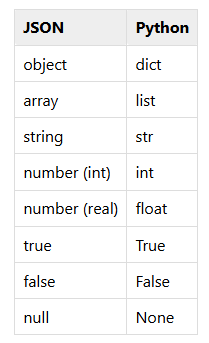

In [1]:
%%HTML
<iframe width="560" height="315" src="https://www.youtube.com/embed/s1PvPvDWG08?si=jLrqTuTGs4rC0y4D" title="YouTube video player" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share" referrerpolicy="strict-origin-when-cross-origin" allowfullscreen></iframe>

## BINARY FILES

Python also supports saving and retrieving binary data to/from files.  To recap:
* Binary is a number system (just like decimal) but with a base of 2 and a legal range of digits {0, 1}
* Each binary digit (a.k.a. bit) is either 1 or 0; there are 8 bits in a byte and 4 bits in a nibble
* The largest value that can be stored in a single byte is 255

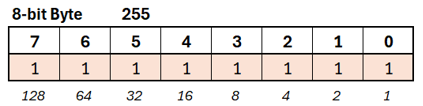

Working with bytes, we prefer the hexadecimal format:
* Hexadecimal is a number system with a base of 16, and a legal range of digits {0, 1, ..., 15}
* To represent a value greater than 9 using a single digit, we use the letters A-F (A=10, B=11, ..., F=15)
* Notice that a hexadecimal digit requires only 4 bits to store the full range of digits

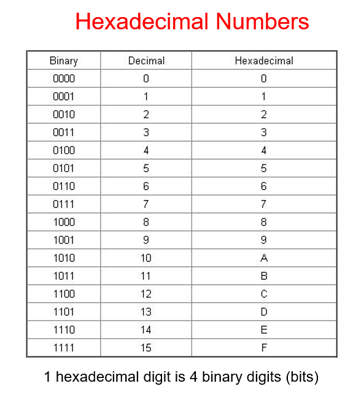


In [34]:
import random

MAX_BYTE = 255

def randomBytes(size):
    """return a list of random bytes of predetermined size"""
    return [random.randrange(0,MAX_BYTE) for _ in range(size)]

def displayBytes(list_of_bytes):
    """display a list of byte values including hex equivalents"""
    print("-"*20)
    for index, item in enumerate(list_of_bytes):
        print(f"{index:<2d} = {item:3d} ({hex(item)})")
    print("-"*20)

def writeBytes(filename, list_of_bytes):
    """write a list of bytes to a file in binary mode"""
    with open(filename, "wb") as f:
        for value in list_of_bytes:
            f.write(value.to_bytes(1, byteorder='big'))

def readBytes(filename):
    data = []
    with open(filename, "rb") as f:
        while True:
            value = f.read(1)
            if not value: break # reached end of the file
            data.append(int.from_bytes(value, byteorder='big'))
    return data


# create list of 10 random byte values and display the data in pretty format
b = randomBytes(10)
print('random bytes created')
displayBytes(b)
writeBytes('data.bin', b)
d = readBytes('data.bin')
print('random bytes read from file')
displayBytes(d)


random bytes created
--------------------
0  = 186 (0xba)
1  = 169 (0xa9)
2  = 168 (0xa8)
3  = 184 (0xb8)
4  =  72 (0x48)
5  = 226 (0xe2)
6  = 165 (0xa5)
7  =  21 (0x15)
8  = 106 (0x6a)
9  = 238 (0xee)
--------------------
random bytes read from file
--------------------
0  = 186 (0xba)
1  = 169 (0xa9)
2  = 168 (0xa8)
3  = 184 (0xb8)
4  =  72 (0x48)
5  = 226 (0xe2)
6  = 165 (0xa5)
7  =  21 (0x15)
8  = 106 (0x6a)
9  = 238 (0xee)
--------------------


## HEXADECIMAL NUMBER SYSTEM
Saving the data [125, 161, 159, 169, 7, 181, 147, 183, 138, 16] as a binary file (data.bin) makes it unreadable to a text editor, but a hex editor is able to read this file.  Opening 'data.bin' in a hex editor reveals that the data was saved to the file in binary format.  

### Text Editor View
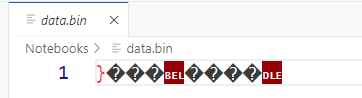

### Hex Editor View
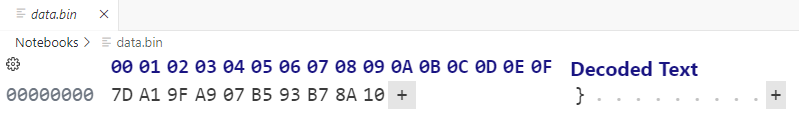

Note in the Hex Editor view, the byte values in hexadecimal format are clearly visible and corresponding exactly with the hex values displayed by the displayBytes( ) function.  The first value in the list is 125 (decimal) which is 0111 1101 (binary).  Each 4-bit (nibble) can be converted to a single hexadecimal digit (0-F) as illustrated by the table above.  In other words, 0111 = 7 and 1101 = 13 (D in hex).

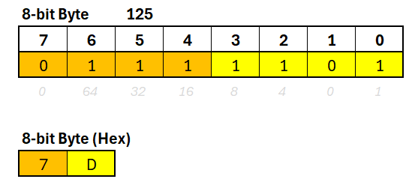

For extra practice, perform the same exercise for the remaining values in the list: [125, 161, 159, 169, 7, 181, 147, 183, 138, 16].  See you can you come up with the same answer as displayed in the hex editor above.

## WRITING STRINGS AS BYTES TO A FILE
Python supports a data type that stores data as bytes.  When transmitting data across networks or saving it to disk, it can be very helpful to encode data into bytes.

In [49]:
msg = "Hello, World"
byte_msg = msg.encode('ascii') # convert string to bytes using ASCII code page
print(byte_msg, '=>', list(byte_msg), '\nhex:',[hex(val)[2:].upper() for val in list(byte_msg)])

with open('hello.bin', "wb") as f:
    f.write(byte_msg)


b'Hello, World' => [72, 101, 108, 108, 111, 44, 32, 87, 111, 114, 108, 100] 
hex: ['48', '65', '6C', '6C', '6F', '2C', '20', '57', '6F', '72', '6C', '64']


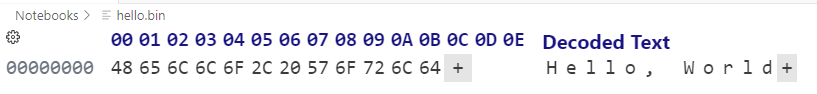

## PICKLING DATA
Writing raw byte data to a file is possible, but not ideal.  Python provides support for writing data structures to file directly from memory.  In the script below, a dictionary is created in memory and then written to disk using the **pickle** libary.  We typically use *dump( )* to write to file and *load( )* to read from file.

In [54]:
import pickle

numbers = [0,1,2,3,4,5,6,7,8,9]
letters = list("ABCDEFGHIJ")
dict_data = dict(zip(numbers, letters))
print(dict_data)

with open('my_data.pkl', 'wb') as f:
    pickle.dump(dict_data, f)

del(dict_data)

with open('my_data.pkl', 'rb') as f:
    my_data = pickle.load(f)

print(my_data)


{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J'}
{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J'}



The real benefit of using the **pickle** module is that we can very easily transer complex data types to disk along with their state.  This advantage is best understood by trying to write the same script BUT *without* using pickling.

In [2]:
player_name = "wayne"
player_level = 4
player_hp = 493
player_gold = 10.5
player_equipment = {"Helm":None, "Shoulder":None, "Chest":"Sheepskin Jerkin", "Belt":"Cloth belt", "Leggings":"Linen pants", "Shoes":None}
map_name = "Castle Town"
active_quests = ["Class quest", "Rescue the girl", "Kill the ogre", "Save the Day", "Collect Lotz of Cloth"]

# saving game state to a file just before you logoff form the game
def save_game(filename):
    game_state = {
        "player_name": player_name,
        "player_hp": player_hp,
        "player_gold": player_gold,
        "player_equipement": player_equipment,
        "map_name": map_name,
        "active_quests": active_quests
    }
    with open(filename, "w") as f:
        print(player_name, file=f),
        
    

# loading game state from file after logging off, so can continuing playing 


{0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E', 5: 'F', 6: 'G', 7: 'H', 8: 'I', 9: 'J'}


## COMPRESSED DATA
Depending on the nature of the non-text data you want to handle, you will most likely use a specific Python library instead of doing all the low-level byte handling yourself.  The Python documentation (https://docs.python.org/3/library/zipfile.html) contains detailed information about how to use this library.


### Writing a Zip File

In [37]:
# add all .txt and .csv files to demo.zip
import os
from zipfile import ZipFile

# get all files in current working directory that have .txt and .csv extensions
documents = []
for filename in os.listdir():
    if filename.endswith(".txt") or filename.endswith(".csv"):
        # Prints only text file present in My Folder
        documents.append(filename)
print(documents)

# add these files to demo.zip
with ZipFile('demo2.zip', "w") as zip:
    for filename in documents:
        print(f"adding {filename} to demo.zip")
        zip.write(filename)
print('archive created')

['animals.txt', 'google_stock_data.csv']
adding animals.txt to demo.zip
adding google_stock_data.csv to demo.zip
archive created


### Reading a Zip File

In [31]:
from zipfile import ZipFile

filename = 'demo.zip'
with ZipFile(filename, 'r') as zip:
    # list the contents of the zip file
    zip.printdir()
    # extract all documents from the zip file
    zip.extractall() # use zip.extract( ) to extract an individual document    

File Name                                             Modified             Size
animals.txt                                    2024-07-27 21:27:00          215
google_stock_data.csv                          2024-07-27 20:45:16       186011


In [32]:
import csv
from zipfile import ZipFile

# get name of files in this archive
filename = 'demo.zip'
with ZipFile(filename, 'r') as zip:
    zip.printdir()
    documents = zip.namelist()
print()

# open and print the contents of the .txt and .csv files
for filename in documents:
    index = filename.find(".")
    extension = filename[index+1:] # file extension
    # PROCESS A TEXT FILE
    if extension == "txt":
        with open(filename, "r") as f:
            text = f.read()
        print('***', filename.upper(), '***')
        print(text)
    # PROCESS A CSV FILE
    elif extension == "csv":
        with open(filename, "r") as csv_file:
            reader = csv.reader(csv_file)
            header = next(reader)
            data = []
            for row in reader:
                data.append(row)
        print('***', filename.upper(), '***')
        print(header) # print header
        print(data[0]) # print first data row
    else:
        print(f'document with {extension} file extension ignored.')


File Name                                             Modified             Size
animals.txt                                    2024-07-27 21:27:00          215
google_stock_data.csv                          2024-07-27 20:45:16       186011

*** ANIMALS.TXT ***
dog
cat
elephant
mouse
chicken
rat
bat
gnat
There are 8 animals.

Paul McCarthy
John Lennon
Ringo Starr
George Harrison
There are 4 members of the Beatles.

*** GOOGLE_STOCK_DATA.CSV ***
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']
['8/19/2014', '585.002622', '587.342658', '584.002627', '586.862643', '978600', '586.862643']
